In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##Открываем датасет, смотрим на данные

###Получение данных

In [ ]:
df1 = pd.read_csv('train.csv')
df1

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
df1_clean = df1.dropna()
df1_clean

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


###Импортируем модель, обучаем

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report

In [ ]:
X = df1_clean[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
y = df1_clean['Survived']

In [ ]:
X_cat = ['Sex', 'Pclass','Embarked']
preprocessor = ColumnTransformer(transformers = [
('cat', OneHotEncoder(drop = 'first', sparse_output = False), X_cat)],
  remainder = 'passthrough')

In [ ]:
encoded_data = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()
X = pd.DataFrame(encoded_data, columns=feature_names)

In [ ]:
model = LogisticRegression(max_iter=7000)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [ ]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=7000)

In [ ]:
model.score(X_train, y_train)

0.7808219178082192

In [ ]:
model.score(X_test, y_test)

0.7567567567567568

In [ ]:
lr_predictions = model.predict(X_test)
print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.73      0.57      0.64        14
           1       0.77      0.87      0.82        23

    accuracy                           0.76        37
   macro avg       0.75      0.72      0.73        37
weighted avg       0.75      0.76      0.75        37



##Делаем более осознанную обработку данных

###Снова получаем данные, обрабатываем

In [ ]:
df2 = pd.read_csv('train.csv')
df2

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Айдишник пассажира в принципе не нужен для обучения модели, как и имя. Сомневаюсь, что номер билета так же мог способствовать выживанию, как и знание номера каюты

###Уберем лишние признаки

In [ ]:
df2_usfl = df2.drop(df2[['PassengerId', 'Name', 'Ticket', 'Cabin']], axis=1)
df2_usfl

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [ ]:
df_dumpster = df2_usfl.dropna()
df_dumpster

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
889,1,1,male,26.0,0,0,30.0000,C


In [ ]:
loss = 100 - ((712/891)*100)
print(f'Потери в данных составят {loss:.4f}% от исходных при удалении NaN')

Потери в данных составят 20.0898% от исходных при удалении NaN


###Работаем с пропусками

In [ ]:
#Посмотрим количество пропусков по столбцам
df2_usfl.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [ ]:
df2_usfl['Age'].median()

28.0

In [ ]:
df2_usfl['Age'].mode()

,Age
0,24.0


####Заполним пропуски в столбце с возрастом медианой

In [ ]:
df2_usfl['Age'] = df2_usfl['Age'].fillna(df2_usfl['Age'].median())
df2_usfl

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


####Заполним пропуски в столбце с портом посадки модой

In [ ]:
df2_usfl['Embarked'] = df2_usfl['Embarked'].fillna(df2_usfl['Embarked'].mode()[0])
df2_usfl

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [ ]:
#Доп проверка на отсутствие NaN-значений
df2_usfl.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


###Посмотрим на статистику по датасету и (частично) визуализируем ее

In [ ]:
df2_usfl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [ ]:
df2_usfl.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


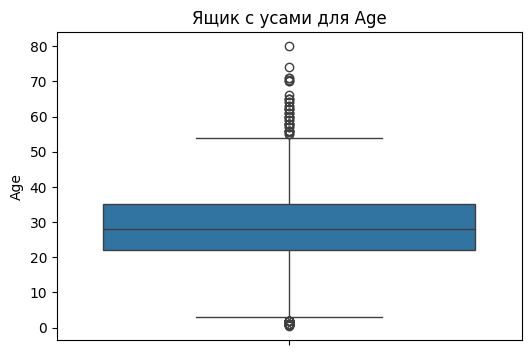

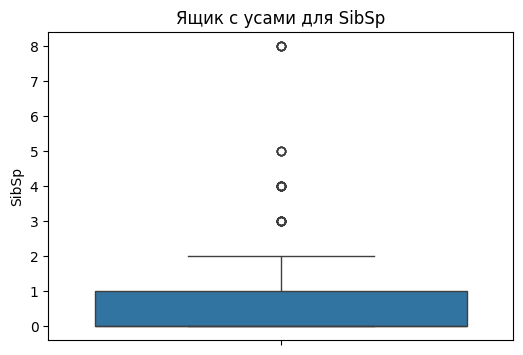

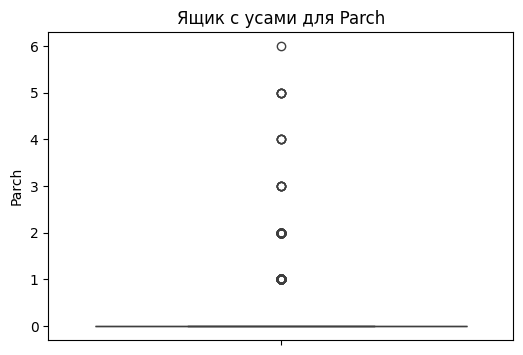

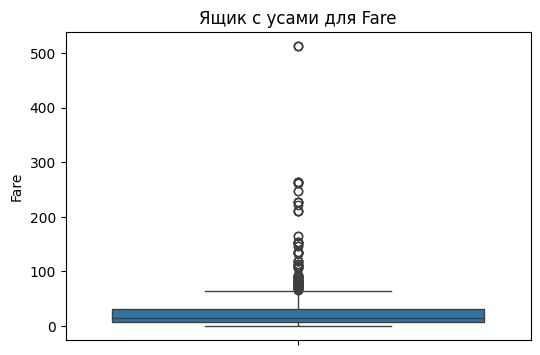

In [ ]:
columns = df2_usfl[['Age','SibSp','Parch','Fare']]
for col in columns:
    plt.figure(figsize = (6, 4))
    sns.boxplot(y = df2_usfl[col])
    plt.title(f'Ящик с усами для {col}')
    plt.ylabel(col)
    plt.show()

Удаление выбросов в данных категориях нецелесообразно, поскольку имеются богатые пассажиры (или те, кто решил прокатиться "зайцем"), возможно многодетные семьи и так далее по списку

##Строим графики по датафрейму

###Распределение пассажиров по полу и классу

In [ ]:
#size - считаем количество строк по классу
#unstack - преобразуем результат в таблицу (из кортежа) для корректной работы
def pclass_hist():
  cls_dist = df2_usfl.groupby(['Sex', 'Pclass']).size().unstack()
  cls_dist.plot(kind = 'bar')
  plt.title('Распределение пассажиров по классу и полу')
  plt.xlabel('Пол')
  plt.xticks(rotation=45)
  plt.ylabel('Количество пассажиров')

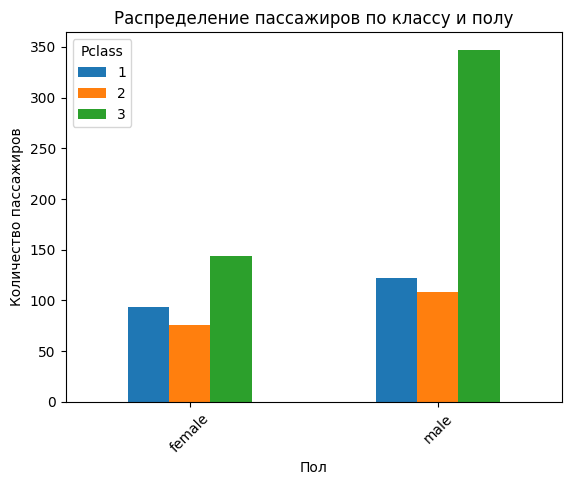

In [ ]:
pclass_hist()

###Медианный возраст пассажиров каждого класса (с учетом пола)

In [ ]:
def age_hist():
  age_dist = df2_usfl.groupby(['Pclass', 'Sex'])['Age'].median()
  age_dist.plot(kind = 'bar')
  plt.title('Распределение пассажиров по классу и медианному возрасту')
  plt.xlabel('Класс, пол')
  plt.xticks(rotation=0)
  plt.ylabel('Медианный возраст')

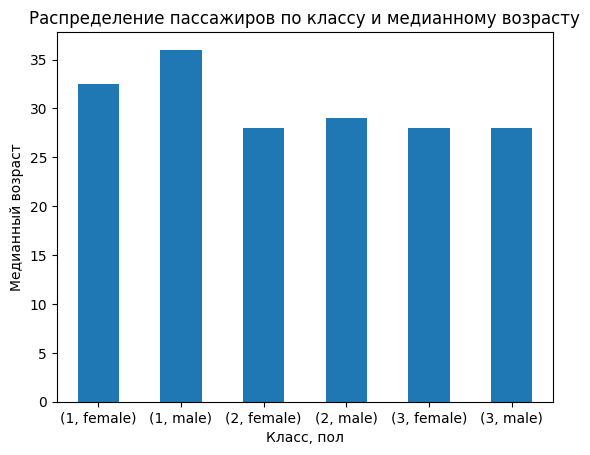

In [ ]:
age_hist()

###Медианный возраст всех пассажиров по полу

In [ ]:
def age_hist1():
  age_dist = df2_usfl.groupby('Sex')['Age'].median()
  age_dist.plot(kind = 'bar')
  plt.title('Распределение пассажиров по полу и медианному возрасту')
  plt.xlabel('Пол')
  plt.xticks(rotation=0)
  plt.ylabel('Медианный возраст')

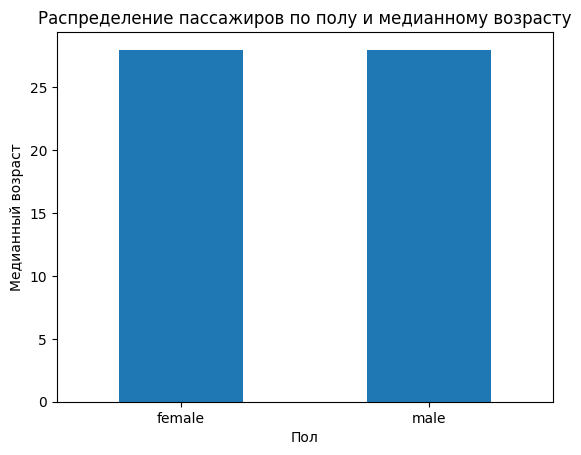

In [ ]:
age_hist1()

##Обучение модели, преобразование признаков

In [ ]:
X = df2_usfl[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
y = df2_usfl['Survived']

In [ ]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [ ]:
#sparse_output=False - вернет массив
X_cat = ['Sex', 'Pclass','Embarked']
preprocessor = ColumnTransformer(transformers = [
('cat', OneHotEncoder(drop = 'first', sparse_output = False), X_cat)],
  remainder = 'passthrough')

In [ ]:
encoded_data = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()
X = pd.DataFrame(encoded_data, columns=feature_names)

In [ ]:
X.head()

,cat__Sex_male,cat__Pclass_2,cat__Pclass_3,cat__Embarked_Q,cat__Embarked_S,remainder__Age,remainder__SibSp,remainder__Parch,remainder__Fare
0,1.0,0.0,1.0,0.0,1.0,22.0,1.0,0.0,7.2500
1,0.0,0.0,0.0,0.0,0.0,38.0,1.0,0.0,71.2833
2,0.0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,7.9250
3,0.0,0.0,0.0,0.0,1.0,35.0,1.0,0.0,53.1000
4,1.0,0.0,1.0,0.0,1.0,35.0,0.0,0.0,8.0500


In [ ]:
model1 = LogisticRegression(max_iter=7000)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [ ]:
model1.fit(X_train, y_train)
predictions = model1.predict_proba(X_test)

In [ ]:
model1.score(X_train, y_train)

0.8103932584269663

In [ ]:
model1.score(X_test, y_test)

0.8044692737430168

In [ ]:
lr_predictions = model1.predict(X_test)
print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       105
           1       0.79      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



Предобработка данных повысила accuracy модели на тренировочных и тестовых данных на 3 и 5% соответственно

####Roc-кривая

In [ ]:
from sklearn.metrics import roc_curve

In [ ]:
fpr, tpr, thres = roc_curve(y_test, predictions[:, 1])

In [ ]:
def roc():
  plt.plot(fpr, tpr)
  plt.title('ROC')
  plt.xlabel('FPR')
  plt.ylabel('TPR')

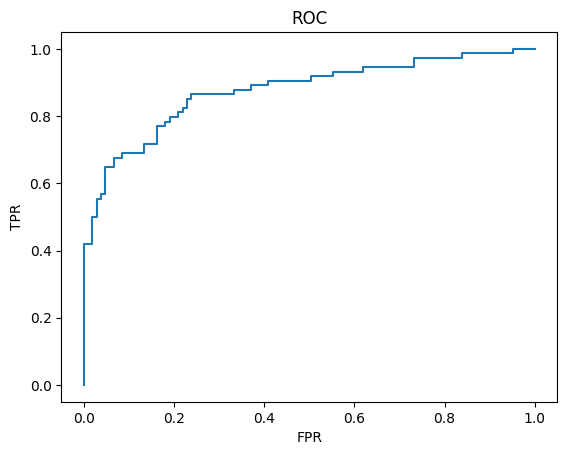

In [ ]:
roc()